## **Proyecto 1 - Leer el voltaje de alimentación con el ADC**

La idea de esta prueba es que el ESP32 lea mediante su **ADC** una tensión proveniente del propio circuito del shield y nos muestre el valor en el Monitor Serie.

Primero, una aclaración importante: el ESP32-S3 **no puede medir directamente 9 V en un pin ADC**. El shield de Freenove ya incorpora un divisor de tensión para reducir ese voltaje a un nivel seguro antes de llevarlo al ADC. Por eso debemos usar el pin y la fórmula que indica Freenove para este kit.

**Paso 1: deja el kit conectado por USB-C**

Usa el mismo USB-C derecho que ya comprobamos que aparece como COM7.

No conectes aún la Rayovac de 9 V.

**Paso 2: abre un sketch nuevo**

En Arduino IDE:

File → New Sketch

```bash
#define PIN_ANALOG_IN 19

void setup() {
  Serial.begin(115200);
}

void loop() {
  int adcVal = analogRead(PIN_ANALOG_IN);

  // Voltaje que realmente llega al pin ADC
  double voltage = adcVal / 4095.0 * 3.3;

  // El shield reduce el voltaje a 1/4
  // Por eso multiplicamos por 4 para recuperar el voltaje de alimentación
  double battery = voltage * 4.0;

  Serial.printf(
    "ADC: %d | Voltaje ADC: %.2f V | Alimentacion: %.2f V\n",
    adcVal,
    voltage,
    battery
  );

  delay(500);
}
```

Con solo el USB conectado:

- Guarda el código si quieres con un nombre como ADC_Voltaje.
- Pulsa ✓ Verify.
- Si compila sin errores, pulsa → Upload.
- Espera hasta que aparezca:
- Hard resetting via RTS pin...
- Abre el Monitor Serie.
- Déjalo en 115200 baud.

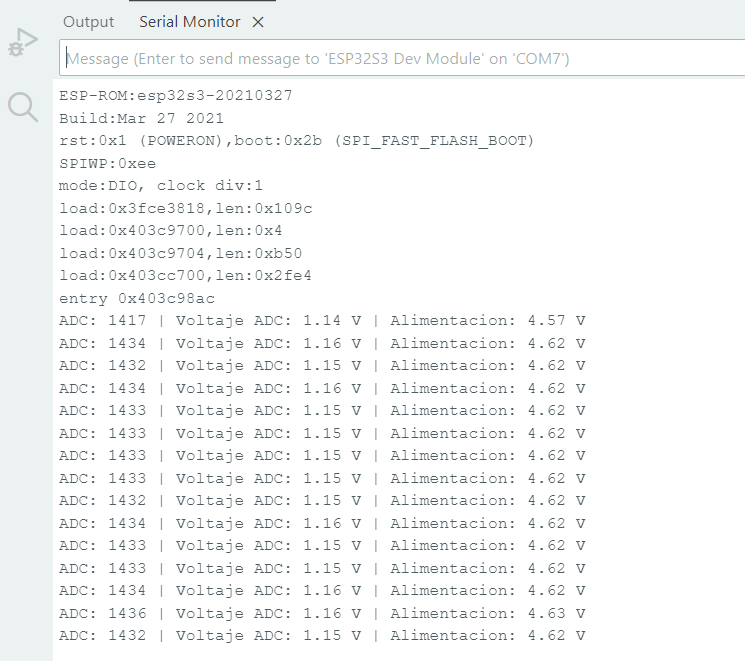

Y aquí hay algo curioso: aunque estés alimentando el kit por USB de 5 V, Freenove dice que esta medición suele dar alrededor de 4 V cuando no hay una fuente externa conectada. Eso es normal por cómo está diseñado el circuito del shield

### **Ahora una segunda medicion, pero con una pila de 9V conectada a la placa**


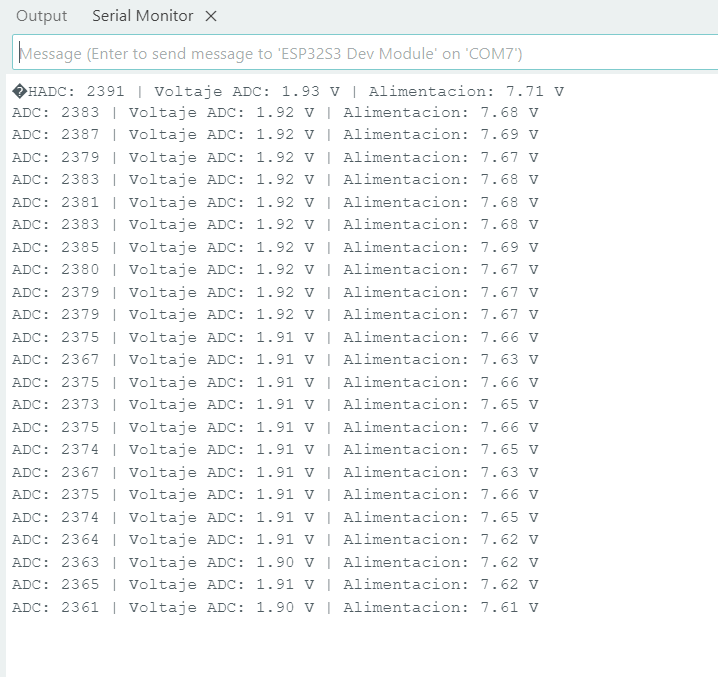

Con la pila conectada, el kit está midiendo aproximadamente:

ADC: ~2360–2390
Voltaje en el GPIO19: ~1,90–1,93 V
Voltaje calculado de alimentación: ~7,6–7,7 V

Eso es claramente distinto de los ~4,62 V que obteníamos únicamente por USB, así que el circuito de medición está respondiendo a la batería.

Ahora bien, una pila nominal de 9 V mostrando ~7,6 V puede deberse a dos cosas principales. Primero, las pilas rectangulares de 9 V tienen una resistencia interna relativamente alta y su tensión puede caer bastante al alimentar una carga como el ESP32-S3 y el shield.

nuestro cálculo:
```bash
adcVal / 4095.0 * 3.3 * 4
```
es una aproximación. El ADC del ESP32 no es un voltímetro de precisión y asumir que su referencia efectiva es exactamente 3,3 V introduce error.

algo interesante: al principio tenías:

7,71 V → 7,68 V → 7,65 V → 7,61 V

Eso podría ser la pila cayendo ligeramente bajo carga mientras funciona el circuito.

Podemos mejorar ahora el experimento

En lugar de calcular los voltios nosotros mismos desde el valor ADC bruto, podemos pedirle al ESP32 que utilice su conversión calibrada en milivoltios.

Cambiamos el loop por:

```bash
void loop() {
  int adcVal = analogRead(PIN_ANALOG_IN);

  uint32_t milivoltios = analogReadMilliVolts(PIN_ANALOG_IN);

  float voltajeADC = milivoltios / 1000.0;

  // Divisor 1:4 del shield Freenove
  float alimentacion = voltajeADC * 4.0;

  Serial.print("ADC: ");
  Serial.print(adcVal);

  Serial.print(" | ADC calibrado: ");
  Serial.print(voltajeADC, 3);
  Serial.print(" V");

  Serial.print(" | Alimentacion: ");
  Serial.print(alimentacion, 2);
  Serial.println(" V");

  delay(500);
}
```

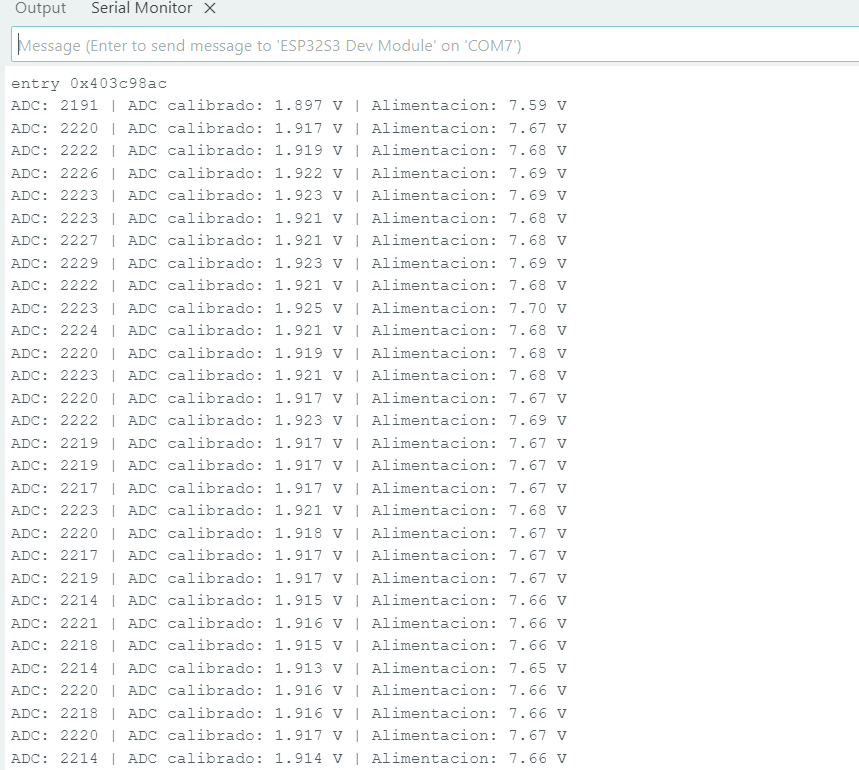

Ahora la lectura está mucho más estable:

ADC calibrado: ~1,915–1,923 V
Alimentación calculada: ~7,66–7,70 V

Eso confirma que **analogReadMilliVolts()** está dando una medición más consistente que la conversión manual anterior.

Lo importante es esto: tu pila de 9 V, bajo la carga del kit, está cayendo a aproximadamente 7,7 V medidos por el circuito del shield. En una pila rectangular de 9 V eso no es raro, porque no está pensada para entregar mucha corriente de forma sostenida. El ESP32-S3, el shield y cualquier periférico adicional pueden hacer que la tensión baje bastante.

También podemos ver que la lectura no está “saltando” mucho: se mantiene alrededor de 7,66–7,70 V, así que el ADC está funcionando bien.

La siguiente prueba útil sería medir esa misma pila con un multímetro mientras sigue conectada. Si el multímetro también muestra algo cercano a 7,7–8,0 V, entonces sabremos que la caída viene principalmente de la batería. Si el multímetro muestra, por ejemplo, 8,8–9,0 V pero el ESP32 sigue calculando 7,7 V, entonces podemos calibrar el factor del divisor para que la lectura del ESP32 sea más precisa.

### **Para medir la pila de 9 V:**

Punta negra al conector COM.
Punta roja al conector de V/Ω.
Enciende el multímetro y selecciona voltaje DC si no entra automáticamente en modo inteligente.
Luego mide en paralelo, no en serie: punta roja al terminal positivo de la pila y negra al negativo.

Importante: no muevas la punta roja al conector de amperios para esta prueba, porque podrías hacer un cortocircuito.

Para nuestro experimento, lo ideal es medir la pila mientras sigue conectada al ESP32 y alimentándolo. Así comparamos exactamente:

Multímetro bajo carga vs. ESP32: ~7,67 V